<a href="https://colab.research.google.com/github/TBGhorbanpour/Social-Awareness/blob/main/PreProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install https://github.com/sobhe/hazm/archive/master.zip --upgrade

  Using cached https://github.com/sobhe/hazm/archive/master.zip
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 8.4 MB/s eta 0:00:00
  Created wheel for hazm: filename=hazm-0.9.3-py3-none-any.whl size=367115 sha256=f89eadf790123ea1591215f9022d2c889ec3e32e6852791e42cc44a1a3bac076
  Stored in directory: /tmp/pip-ephem-wheel-cache-9me3enqz/wheels/05/ea/1e/6430db303b63b42635e95a99261576306ee8ae7dd9400633b0
Successfully built hazm
  Attempting uninstall: nltk
    Found existing installation: nltk 3.3
    Uninstalling nltk-3.3:
      Successfully uninstalled nltk-3.3
  Attempting uninstall: hazm
    Found existing installation: hazm 0.7.0
    Uninstalling hazm-0.7.0:
      Successfully uninstalled hazm-0.7.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the f

In [ ]:
!pip install wordcloud-fa


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.7/316.7 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 16.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for nltk: filename=nltk-3.3-py3-none-any.whl size=1394471 sha256=b543a39565765fbf2e474a76ae7c0ca6d34da9bcc30e2de9817b26f65c53c60e
  Stored in directory: /root/.cache/pip/wheels/6b/6d/14/3defa4cd7013faeddf715150696f4a96d7725c87700eb8a68e
  Created wheel for libwapiti: filename=libwapiti-0.2.1-cp310-cp310-linux_x86_64.whl size=179233 sha256=7083bdd7ba727fab2d6d763eda682b6016197aa81529625ff24da0c930a12b0d
  Stored in directory: /root/.cache/pip/wheels/9f/cb/30/fef48ecac051e433987eccdb5682900b4c00d44a4bcd4d4ec8
Successfully built nltk libwapiti
  Attempting uninstall: nltk
    F

In [ ]:
###!pip3 install googletrans==3.1.0a0

In [ ]:
!pip install langdetect

In [ ]:
!pip install arabic_reshaper python-bidi

In [ ]:
!apt-get install -y fonts-farsiweb

In [ ]:
from bidi.algorithm import get_display
import arabic_reshaper
def make_farsi_text(x):
  reshaped_text = arabic_reshaper.reshape(x)
  farsi_text = get_display(reshaped_text)
  return farsi_text



font_title = {'family': 'B Farnaz',
'color': 'red',
'weight': 'normal',
'size': 30,
}
font_labels = {'family': 'B Nazanin',
'color': 'black',
'weight': 'normal',
'size': 20,
}

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import re

from hazm import word_tokenize, Normalizer, sent_tokenize, Lemmatizer
from wordcloud_fa import WordCloudFa

from gensim.models import Word2Vec
import networkx as nx


**StopWords**

In [ ]:
f= open(r"The Final.txt",'r', encoding="utf8")
SWord = f.readlines()
stopwords = [sw[:-1] for sw in SWord]


#f= open(r"Final StopWord.txt",'r', encoding="utf8")
#SWord = f.readlines()
#SWord=SWord.drop_duplicates(subset=['StopWord'], keep='last')

#delete duplicates in Final StopWord
#result = [*set(SWord)]

#stopwords = [sw[:-1] for sw in result]

**Preprocess Functions**

In [ ]:
class preprocess:
    def tlt(cls, intab, txt):
        return txt.translate({ord(k): v for k ,v, in zip(intab,outtab)})

    def normalizasion(self, text):
        normalizer= Normalizer()
        return normalizer.normalize(text)

    def lemmatize_hazm(self,doc_string):
        text=' '
        words= word_tokenize(doc_string)
        lemmatizer = Lemmatizer()
        for item in words:
            wordlema = lemmatizer.lemmatize(item)
            if '#' in wordlema:
                text = text + wordlema.split("#")[0] + ' '
            else:
                text = text + wordlema + ' '
        return text

   #### def formal_Converter_Hazm(self, text):

    def handle_correct_alphabets(self, doc_string):
        multiple_subs=[
            (r'اً|اٌ|اٍ|أ|إ|ا|آ', r'ا'),
            (r'ی|ي|ی|ۍ|ے|ێ',r'ی'),
            (r'ﻜ|ﻚ|ك|ڪ|ک|ک',r'ک'),
            (r'(\n)+',r'\n'),
            (r'0|۰|٠',r'۰'),
            (r'1|۱|١',r'۱'),
            (r'2|۲|٢',r'۲'),
            (r'3|۳|٣',r'۳'),
            (r'4|۴|٤',r'۴'),
            (r'5|۵|٥',r'۵'),
            (r'6|۶|٦',r'۶'),
            (r'7|۷|٧',r'۷'),
            (r'8|۸|٨',r'۸'),
            (r'9|۹|٩',r'۹'),
        ]
        for old, new in multiple_subs:
            doc_string = re.sub(old, new, doc_string)
        return doc_string

    def handle_convert_punctuation(self, doc_string):
        # !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
        multiple_subs=[
            (r'[?|؟]',r'؟'),
            (r'[,|،|٬|٫]',r'،'),
            (r'[%|٪]',r'%')
        ]
        for item in multiple_subs:
            doc_string = re.sub(item[0], item[1], doc_string)
        return doc_string

    def handle_remove_stopwords(self, doc_string):
        text = ' '
        tokens = doc_string.split()
        for words in tokens:
            if words not in stopwords:
                text = text + words + ' '
        return text
        ##################################################################


        ############################################################################
    def clean(self, text, remove_stopwords=True,
              remove_email=True, remove_urls=True, remove_digits=True):

        text=self.handle_correct_alphabets(text)

        text=self.handle_convert_punctuation(text)

        #remove mentions , hashtag , urls
        #if remove_urls:

            #text = re.sub(r"(?:\@|#\S+|https?\://)\S+"," ",text)
            #text = re.sub(r'(https?://\S+)|www\.\S+|\b\w+\.\w{2,3}/\S+|\b\w+\.\w{2,3}', '', text)
            #text = re.sub(r'https://t\.co/\w+|@\w+|#\w+', '', text)
            #text = re.sub(r'https://t\.co/\w+', '', text)


        #remove email
        if remove_email:
            text = re.sub(r"\b[\w.%+-]+@[\w.-]+\.[a-zA-Z]{2,6}\b"," ",text)

        #Remove number
        if remove_digits:
            text= re.sub(r"\d",'',text)

        #Seprate non persian characters or words from persian characters or words
        text = re.findall(r"[\dA-Za-z._]+|[^\dA-Za-z\W]+",text,re.UNICODE)
        text= ' '.join(word for word in text)

        #replace new line characters
        text= re.sub (r'[\r\n\r\n]+',' ',text)
        #text= re.sub('\r?\n',' . ',text)
        text= re.sub('-{3}',' ',text)
        text= re.sub('-{2}',' ',text)

        #replace three ... dots with one
        text= re.sub("\s*\.{3,}",' . ',text)
        text= re.sub("\s*\.{2,}",' . ',text)

        #می و نمی could be separate nouns and not prefix
        text = re.sub(r"\s+(ن?می)\s+",r' \1',text)

        # های و تر could be seprate nouns and not suffix
        #text = re.sub(r"\s+?(?(ن)ی)تر?\s+",r'\1',text)
        #text = re.sub(r"\s+((ی) ی)ها\s+",r'\1',text)
        text = re.sub("\s+(تر(ین)?)\s+",r'\1 ',text)
        text = re.sub("\s+(تری?)\s+",r'\1 ',text)
        text = re.sub("\s+(های?)\s+",r'\1 ',text)
        text = re.sub("\s+(گیری)\s+",r'\1 ',text)

        #Aggressive
        text = re.sub(r"(!){2,}",r'\1',text)
        text = re.sub(r"(؟){2,}",r'\1',text)

        #replace more than one space
        text= re.sub("[ ]+",u' ',text)
        text = re.sub(r"([\n]+)[ \t]*",r'\1',text)

        #Remove Extended char
        text = re.sub(r"-+|_",r' ',text)

        #space after colon separate time part
        text = re.sub(r"([۰-۹]+):\s+([۰-۹]+)",r'\1:\2',text)

        #Remove tag
        p = re.compile(r'<.*?>')
        text = p.sub('', text)

        # Punctuation can be placed in the stopwords file and remove
        if remove_stopwords:
            text = self.handle_remove_stopwords(text)

        text.strip()

        return text

In [ ]:
################################
def remove_urls(text):
    if isinstance(text, str):  # Check if the input is a string
        text = re.sub(r'https?://\S+|www\.\S+', '', text)
    return text

def remove_mentions(text):
    if isinstance(text, str):
        text = re.sub(r'@\w+', '', text)
    return text

def remove_hashtags(text):
    if isinstance(text, str):
        text = re.sub(r'#\w+', '', text)
    return text

**Tweets Preprocessing**

In [ ]:
import pandas as pd
df = pd.read_csv('normalized_dataset.csv')
df.head(10)

In [ ]:
df.shape

(2321, 10)

# Language Dtection

In [ ]:
############################# this is toooooooo slow for large database
#######################################################################
from googletrans import Translator
import csv

translator = Translator()
df["language"] = ''
language=[]

for item in df['Tweet']:
  lang = translator.translate(item)
  language.append(lang.src)

df['language'] = language
df=df[df['language'].str.contains("fa")]

df.shape
df.head(10)


In [ ]:
##############################Done it already#################################
from langdetect import detect
import pandas as pd

df["language"] = ''

for index, row in df.iterrows():
    tweet = row["Tweet"]
    if len(tweet) > 2:  # Minimum length requirement
        try:
            lang = detect(tweet)
            df.at[index, "language"] = lang
        except:
            df.at[index, "language"] = "unknown"
    else:
        df.at[index, "language"] = "unknown"

df = df[df["language"] == "fa"]

In [ ]:
df.head(10)

In [ ]:
df.to_csv('Persian water .csv', sep=',', index=False, encoding='utf-8-sig')

#Convert Informal to Formal by Farsiyar

In [ ]:
import requests
import json

def callApi(url, data, tokenKey):
    headers = {
        'Content-Type': "application/json",
        'Authorization': "Bearer " + tokenKey,
        'Cache-Control': "no-cache"
    }
    response = requests.request("POST", url, data=data.encode("utf-8"), headers=headers)
    return response.text

In [ ]:

##################### Get Token by Api Key ##########################
baseUrl = "http://api.text-mining.ir/api/"
url = baseUrl + "Token/GetToken"
querystring = {"apikey":"20a0fcbf-b42e-ee11-9abe-d397223d3fbe"}
response = requests.request("GET", url, params=querystring)
data = json.loads(response.text)
tokenKey = data['token']
#data
tokenKey

In [ ]:
################ Call Slang to Formal Converter ##################
url =  baseUrl + "TextRefinement/FormalConverter"
formal=[]

for row in df['Tweet']:
    slang = f'''"{row}"'''
    slang_Converter = callApi(url, slang, tokenKey)
    formal.append(slang_Converter)

df['Tweet'] = formal


df.head(10)

# Countries Filter


In [ ]:
#import pandas
#countries=pandas.read_fwf('Countries.txt', index=None)
#countries.head(10)

#type(countries)

pandas.core.frame.DataFrame

In [ ]:
#countries
df = df.dropna()  # Remove rows with missing or NaN values


df.drop(df[df['Tweet'].str.contains('کربلا|اسکاتلند|اسکاندیناوی|آذربایجان| آرژانتین| آفریقای جنوبی| آفریقای مرکزی| آلبانی| آلمان| آنتیگوا و باربودا| آندورا| آنگولا| اتریش| اتیوپی| اردن| ارمنستان| اریتره| ازبکستان| اسپانیا| استرالیا| استونی| اسلوواکی| اسلوونی| افغانستان| اکوادور| الجزایر| السالوادور| امارات متحده عربی| امریکا| اندونزی| انگلستان| اوروگوئه| اوکراین| اوگاندا| ایتالیا| ایرلند| ایسلند| باربادوس| باهاما| بحرین| برزیل| برونئی| بریتانیا| بلاروس| بلژیک| بلغارستان| بلیز| بنگلادش| بنین| بوتان| بوتسوانا| بورکینافاسو| بوروندی| بولیوی| پاپوا گینه نو| پاراگوئه| پاکستان| پاناما| پرتغال| پرو| تاجیکستان| تانزانیا| تایلند| ترکمنستان| ترکیه| ترینیداد و توباگو| توگو| تونس‌‌| تونگا| تووالو| جامائیکا| جیبوتی| چاد| چک| چین| چین تایپه| دانمارک| دومنیکا| دومنیکن| روآندا| روسیه| رومانی| زئیر| زامبیا| زلاند نو| زیمباوه| ژاپن| سائوتومه و پرنسیپ| ساحل عاج| ساموای غربی| سان مارینو| سریلانکا| سلیمان| سنت کریستوفر و نویس| سنت لوسیا| سنت وینست و گرنادین| سنگاپور| سنگال| سوازیلند| سوئد| سودان| سورینام| سوریه| سومالی| سوئیس| سیرالئون| سیشل| شیلی| صربستان| عراق| عربستان سعودی| عمان| غنا| فرانسه| فنلاند| فیجی| فیلیپین| قبرس| قرقیزستان| قزاقستان| قطر| کامبوج| کامرون| کانادا| کرواسی| کره جنوبی| کره شمالی| کاستاریکا| کلمبیا| کنگو| کنیا| کوبا| کوت دیووار| کومور| کویت| کیپ ورد| کیریباس| گابون| گامبیا| گرانادا| گرجستان| گواتمالا| گویان| گینه| گینه استوائی| گینه بیسائو| لائوس| لاتوی| لبنان| لسوتو| ماسدونیا| ماداگاسکار| مالاوی| مالزی| مالدیو| مالی| مالتا| جزایر مارشال| ماریتانیا| ماریتیوس| مکزیک| ایالات فدرالی میکرونزیا| مولدوا| موناکو| مونگل| مونتنگرو| مراکش (موراکو)| موزامبیک| میانمار| مجارستان| مصر| نامیبیا| نارو| نپال| نیوزیلند| نیکاراگوئه| نایجر| نیجریه| وانوآتو| واتیکان| ونزوئلا| ویتنام| هند| هندوراس| هلند| یمن| یونان| یوگوسلاوی ')].index, inplace= True)

#df[~df['Tweet'].isin(countries)].dropna()
df.shape
df.head(10)


##


In [ ]:
df.shape

(2291, 10)

In [ ]:
df['Tweet'] = df['Tweet'].apply(remove_urls)
df['Tweet'] = df['Tweet'].apply(remove_mentions)
df['Tweet'] = df['Tweet'].apply(remove_hashtags)

In [ ]:
######### Normalize ############
prep = preprocess()

df['Tweet'] = df['Tweet'].apply(lambda x: prep.normalizasion(x))

In [ ]:
df['Tweet'] = df['Tweet'].apply(lambda x: prep.lemmatize_hazm(x))

In [ ]:
#########################Tokenization with Hazm##########################



import pandas as pd
from hazm import word_tokenize


df = pd.read_csv('normalized_dataset.csv')

#df['tokens'] =[]
def tokenize_text(text):
    if pd.notna(text):  # Check if 'text' is not NaN
        return word_tokenize(text)
    else:
        return []

df['tokens'] = df['fully_cleaned_text'].apply(tokenize_text)

# Save the DataFrame back to a new CSV file with the tokenized data
output_csv_file_path = 'Hazm_Tokenized.csv'
df.to_csv(output_csv_file_path, index=False, encoding='utf-8')






In [ ]:
df.to_csv('result96.csv', sep=',', index=False, encoding='utf-8-sig')

In [ ]:
df.head(10)

In [ ]:

 ############ Remove stopwords,...##########
df['Tweet'] = df['Tweet'].apply(lambda x: prep.clean(x))

df.to_csv('result .csv', sep=',', index=False, encoding='utf-8-sig')

In [ ]:
df.head()

# delete duplicate & null & certain length

In [ ]:

df=df.drop_duplicates(subset=['Tweet'], keep='last')
df[~df['Tweet'].isnull()]



df=df.loc[df['Tweet'].str.len() > 20]
#df[df['Tweet'].map(len) > 500]
#df = df[df.text_length  >  80]
df.shape

(2291, 10)

# Graph


In [ ]:
from gensim.models import Word2Vec
from hazm import word_tokenize

df = pd.read_csv('prepare for graph.csv')###############

# Preprocess the tweets and convert them into a list of lists format
preprocessed_tweets = [word_tokenize(tweet) for tweet in df['Tweet']]

# Train the Word2Vec model
model = Word2Vec(preprocessed_tweets, vector_size=100, window=5, min_count=1, workers=4)

# Get the words in the vocabulary
vocabulary = list(model.wv.key_to_index.keys())

# Print the words in the vocabulary
for word in vocabulary:
    print(word)

Streaming output truncated to the last 5000 lines.
مگنت
خداحافظی
انزوا
واگذاری
بمونید
وشو
میبارد
معادل
توده
سواری
ثانی
اندازهگیری
سکو
ایرانیهای
انفولانزا
فروشگاه
مطالعات
چندمین
مرتبه
معمار
طبیعیه
بیفتن
هفتس
ییلاق
مامان
گری
موسم
دقیق
ضروریست
پیاپی
ناامیدی
خطرن
باتوجه
درکشور
عظیم
انوقت
دلسوز
دامدار
هرچقدر
محمود
صیاد
کاسپین
قضاوت
میکروپلاستیکها
غبارالود
تعویض
سخنرانیهای
مدافع
پیمانکار
ساختگی
درعین
بالغ
مطالبات
سکونته
اذان
ریاکار
میرود
مهره
زمینمون
اینرو
بلوغ
فلاورجان
مسوولان
بخشیدن
متحده
مستعان
ایالات
انحراف
انتن
بدتری
رادیو
اکتیو
پنجشنبه
تابلو
خشکیده
بچگی
نیسان
هاس
گارد
هابیت
برنمیگردد
دگ
ناظر
وبلوچستان
خسارات
میبایست
بواسطه
هربار
جایگاه
رغم
ق
استودیو
ابکی
نخ
عن
ارگانیک
دماوند
غیربهداشتی
حراست
بشوری
یادمان
ببارد
تکون
مجوز
سپر
کوچ
نون
چقدره
درسال
تخصیص
کارت
استراحت
رانش
سومین
دوسالانه
پرستار
صدم
ایکاش
تعطیله
مضرات
خفگی
اهوازه
اغاز
پرفشار
منطقیه
ظالمانه
لشکر
فارغ
شیراب
رگ
ایراد
تحریک
رستوران
تحقیر
باگت
طنز
نیتروژن
بهمن
ناسا
انتقادات
نظرات
co
امایش
مروارید
سرازیر
توهمات
ذبالههای
وقایع
واسطه

In [ ]:

normalizer = Normalizer()
def preprocess_tweet(tweet):
    #tweet = re.sub(r"http\S+|www\S+|https\S+", "", tweet)
    tweet = normalizer.normalize(tweet)
    return tweet

# Apply the preprocessing function to the 'Tweet' column
df['Tweet'] = df['Tweet'].apply(preprocess_tweet)

#Apply R2L direction and make the text Persian in display
df['Tweet'] = df['Tweet'].apply(make_farsi_text)

# Tokenize the tweets using the word_tokenize function from Hazm
df['Tokenized'] = df['Tweet'].apply(word_tokenize)

# Train the Word2Vec model
model = Word2Vec(df['Tokenized'], vector_size=100, window=5, min_count=1, workers=4)

# Test the model
similar_words = model.wv.most_similar('الود')  # Replace 'word' with any word from your dataset
# Train the Word2Vec model
for word, score in similar_words:
    print(word, score)


# Train the Word2Vec model
#model = Word2Vec(df['Tokenized'], size=100, window=5, min_count=1, workers=4)

# Test the model
#model.wv.most_similar('جنگل')  # Replace 'word' with any word from your dataset


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


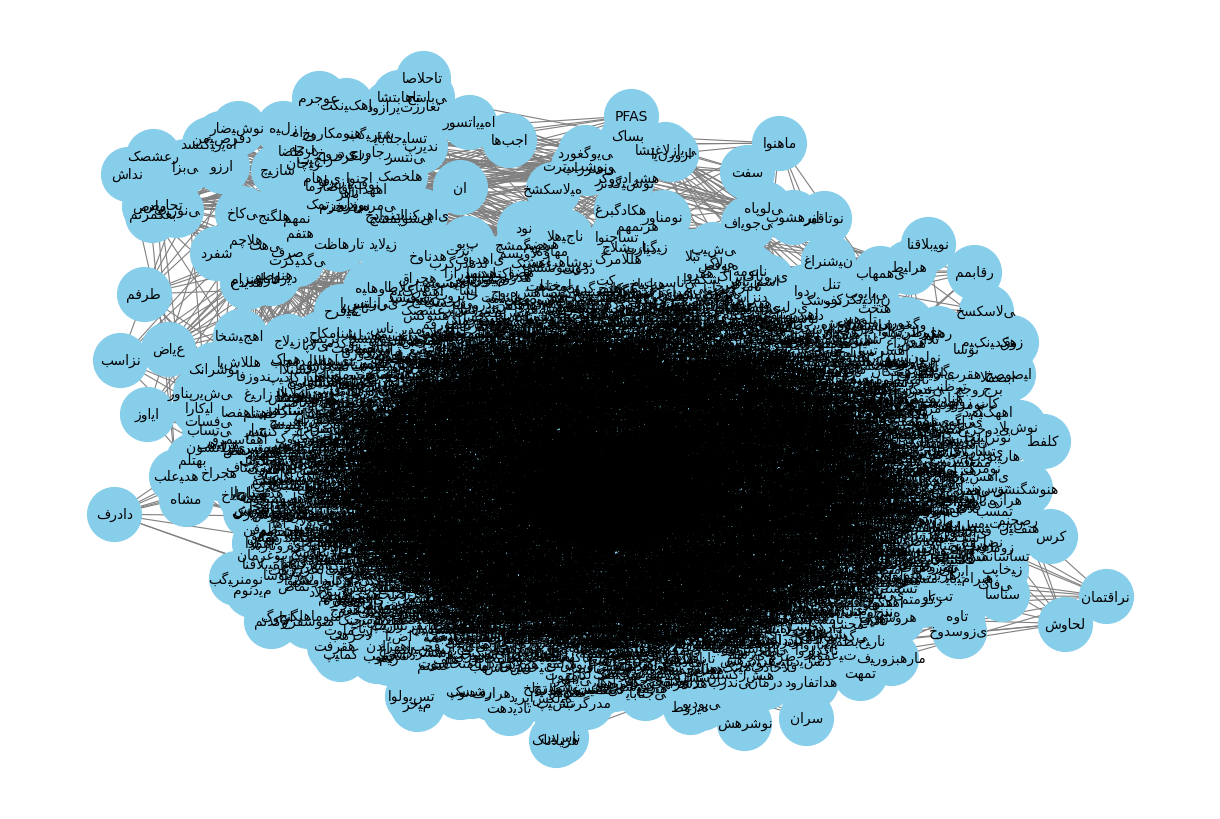

In [ ]:
# Create an empty graph
graph = nx.Graph()

# Add nodes to the graph
for word in model.wv.index_to_key:
    graph.add_node(word)

# Add edges based on word similarities
for word in model.wv.index_to_key:
    similar_words = model.wv.most_similar(word)
    for sim_word, sim_score in similar_words:
        graph.add_edge(word, sim_word, weight=sim_score)

# Plot the graph
df['Tweet'] = df['Tweet'].apply(make_farsi_text)
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(graph, k=0.1)
nx.draw(graph, pos, with_labels=True, node_color='skyblue', node_size=1500, font_size=10, edge_color='gray', width=0.8)
plt.show()


**Co-Currence Graph**

In [ ]:
import pandas as pd
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('prepare for graph.csv')
df['Tweet'] = df['Tweet'].apply(make_farsi_text)

# Create an empty co-occurrence matrix
cooccurrence_matrix = pd.DataFrame(0, index=df['Tweet'], columns=df['Tweet'])
df['Tweet'] = df['Tweet'].apply(make_farsi_text)

# Iterate over each row in the DataFrame and update the co-occurrence matrix
for _, row in df.iterrows():
    tokens = set(row['Tweet'].split())  # Split the preprocessed text into tokens
    for word1, word2 in combinations(tokens, 2):
        try:
            cooccurrence_matrix.at[word1, word2] += 1
            cooccurrence_matrix.at[word2, word1] += 1
        except KeyError:
            pass


In [ ]:
# Create an empty graph
graph = nx.Graph()

# Add nodes to the graph
graph.add_nodes_from(cooccurrence_matrix.columns)

# Add weighted edges to the graph based on the co-occurrence matrix
for word1 in cooccurrence_matrix.columns:
    for word2 in cooccurrence_matrix.columns:
        weight = cooccurrence_matrix.at[word1, word2]
        if weight > 0:
            graph.add_edge(word1, word2, weight=weight)


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


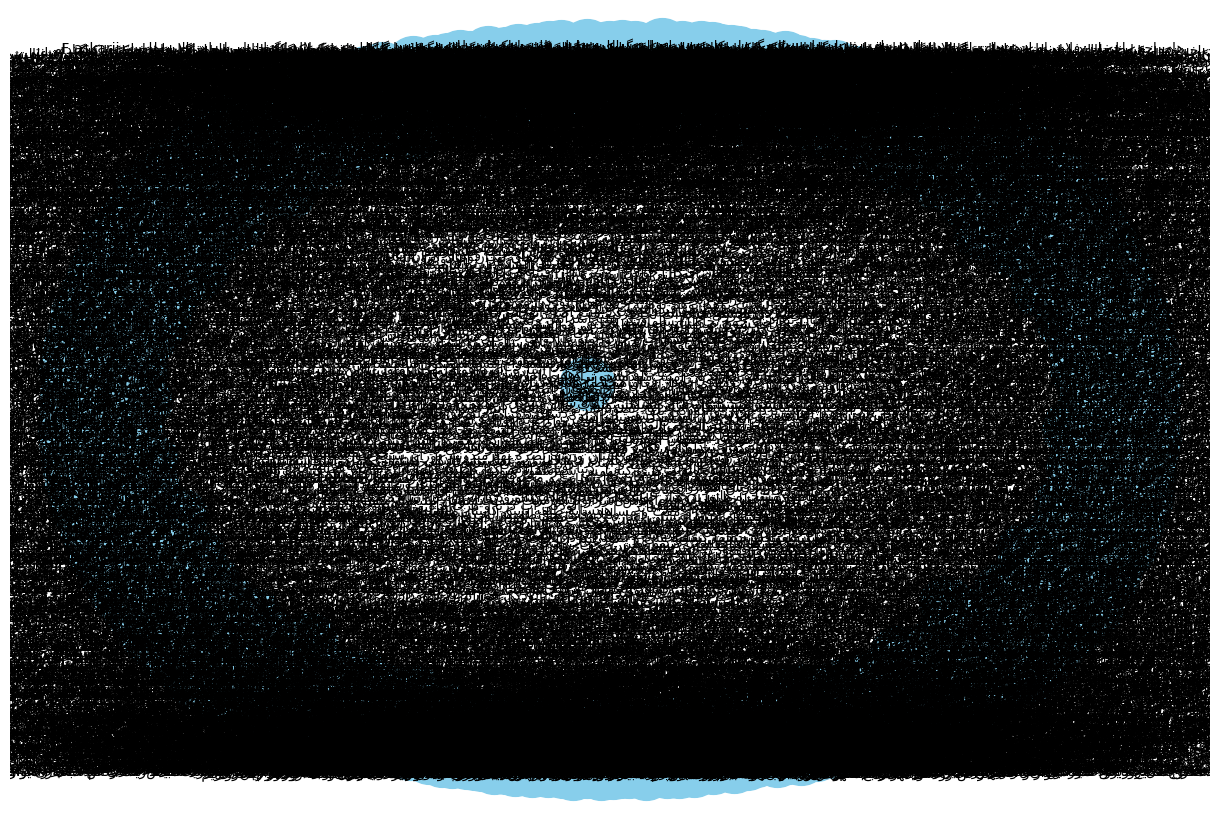

In [ ]:
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(graph, k=0.1)
nx.draw(graph, pos, with_labels=True, node_color='skyblue', node_size=1500, font_size=10, edge_color='gray', width=0.2)
plt.show()


In [ ]:
# Calculate betweenness centrality
centrality_scores = nx.betweenness_centrality(graph)

# Sort nodes based on betweenness centrality scores in descending order
sorted_nodes = sorted(centrality_scores, key=centrality_scores.get, reverse=True)

# Adjust the importance threshold to retain a desired number of nodes or a fraction of the nodes
importance_threshold = 0.099  # Set the desired importance threshold############################################Change
desired_num_nodes = int(importance_threshold * len(graph))

# Remove nodes until the graph is not empty or the desired number of nodes is reached
for node in sorted_nodes[desired_num_nodes:]:
    graph.remove_node(node)

if len(graph) > 0:
    print("Non-empty graph after filtering.")
else:
    print("Empty graph after filtering.")



Empty graph after filtering.


In [ ]:
degree_threshold = 1  # Set the minimum degree threshold

# Get nodes with degrees below the threshold
nodes_to_remove = [node for node, degree in graph.degree() if degree < degree_threshold]

# Check if removing the nodes will result in an empty graph
if len(nodes_to_remove) < len(graph.nodes()):
    graph.remove_nodes_from(nodes_to_remove)
else:
    print("No nodes left in the graph after filtering.")



No nodes left in the graph after filtering.


# Topic Modeling Graph

In [ ]:
!pip install gensim
!pip install scikit-learn


In [ ]:
from gensim import models
from gensim.corpora import Dictionary
from hazm import word_tokenize


preprocessed_text_data = df['Tweet']

# Tokenize your preprocessed text data
tokenized_data = [word_tokenize(doc) for doc in preprocessed_text_data]

# Create a dictionary from the tokenized data
dictionary = Dictionary(tokenized_data)

# Create a document-term matrix
doc_term_matrix = [dictionary.doc2bow(doc) for doc in tokenized_data]

# Apply LDA topic modeling
lda_model = models.LdaModel(doc_term_matrix, num_topics=10, id2word=dictionary, passes=10)



In [ ]:
# Get the topics and associated keywords
topics = lda_model.show_topics(num_topics=10, num_words=10)

# Print the topics and their keywords
for topic in topics:
    print(topic)


(0, '0.111*"ﻭ" + 0.053*"ﺍﺏ" + 0.046*"ﺍﻟﻮﺩﮔﯽ" + 0.023*"ﻫﻮﺍ" + 0.007*"ﺍﯾﺮﺍﻥ" + 0.005*"ﺑﺤﺮﺍﻥ" + 0.005*"ﺯﯾﺴﺖ" + 0.005*"ﺍﺻﻔﻬﺎﻥ" + 0.005*"ﺍﺳﺘﺎﻥ" + 0.005*"ﻭﻗﺖ"')
(1, '0.095*"ﻭ" + 0.028*"ﺍﺏ" + 0.026*"ﺍﻟﻮﺩﮔﯽ" + 0.020*"ﻫﻮﺍ" + 0.009*"ﺧﺎﮎ" + 0.008*"ﻣﻨﺎﺑﻊ" + 0.008*"ﺍﯾﺮﺍﻥ" + 0.008*"ﮐﻤﺒﻮﺩ" + 0.007*"ﻧﺎﺑﻮﺩﯼ" + 0.007*"ﺑﺤﺮﺍﻥ"')
(2, '0.015*"ﺷﻬﺮﮎ" + 0.009*"ﻗﺮﻧﯿﻪ" + 0.007*"ﺩﺳﺘﻪ" + 0.006*"ﻣﺠﻠﺲ" + 0.005*"ﮐﺎﺭﺕ" + 0.005*"ﻟﯿﻤﻮ" + 0.005*"ﺍﺳﺘﺮﺍﺣﺖ" + 0.005*"ﺑﺮﺍﺛﺮ" + 0.005*"ﻣﻮﻓﻘﯿﺖ" + 0.005*"ﺯﻧﺎ"')
(3, '0.019*"ﺗﻮﺑﻪ" + 0.015*"ﻭﺿﻮ" + 0.008*"ﺫﺭﺍﺕ" + 0.007*"ﮔﺮﻭﻥ" + 0.006*"ﻣﺎﺳﮏ" + 0.005*"ﺗﺎﺭ" + 0.005*"ﻣﯿﮑﺮﻭﺑﯽ" + 0.005*"ﺧﺪﺍﯾﺎ" + 0.005*"ﭼﺸﻢ" + 0.005*"ﺳﯿﻦ"')
(4, '0.034*"ﺣﻞ" + 0.031*"ﻣﺸﮑﻞ" + 0.020*"ﻫﻮﺍ" + 0.017*"ﺯﯾﺴﺖ" + 0.017*"ﺍﻟﻮﺩﮔﯽ" + 0.016*"ﺧﯿﺎﻝ" + 0.016*"ﺍﺏ" + 0.013*"ﻣﺤﯿﻂ" + 0.013*"ﻭ" + 0.009*"ﭘﻔﯿﻮﺯ"')
(5, '0.135*"ﻭ" + 0.053*"ﺍﻟﻮﺩﮔﯽ" + 0.051*"ﺍﺏ" + 0.027*"ﻫﻮﺍ" + 0.008*"ﺧﺎﮎ" + 0.007*"ﻏﺬﺍ" + 0.007*"ﻣﺤﯿﻂ" + 0.006*"ﺯﯾﺴﺖ" + 0.005*"ﻣﺎﻩ" + 0.005*"ﺗﻬﺮﺍﻥ"')
(6, '0.076*"ﺍﺏ" + 0.053*"ﻭ" + 0.045*"ﺍﻟﻮﺩﮔﯽ" + 0.011*"ﺗﻬﺮﺍﻥ" + 0.011*"ﻫﻮﺍ"

Topic-Topic Graph:

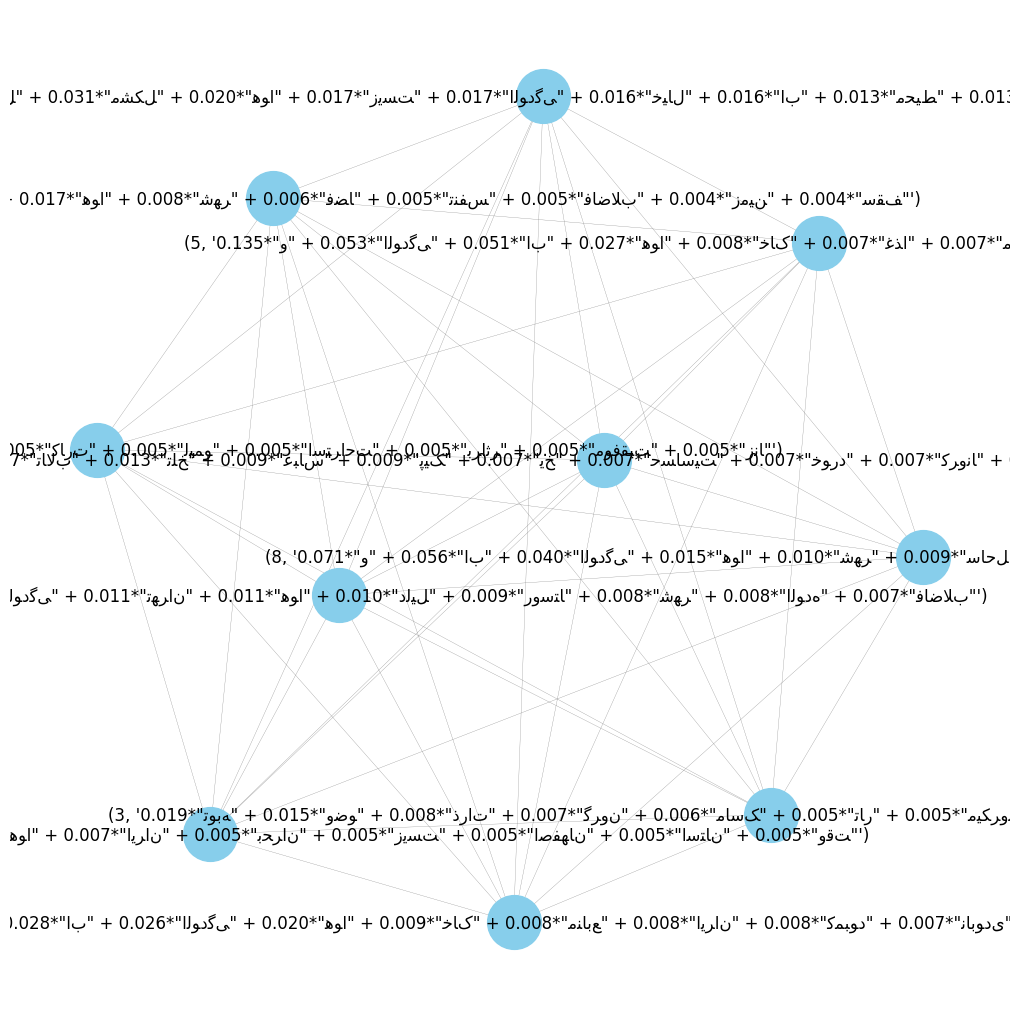

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create an empty graph
graph = nx.Graph()

# Add nodes to the graph (topics)
for topic in topics:
    graph.add_node(topic)

# Add edges based on topic similarity
for i in range(len(topics)):
    for j in range(i+1, len(topics)):
        #similarity = calculate_similarity(topics[i], topics[j])  # Calculate similarity between topics
        similarity = 0.5
        graph.add_edge(topics[i], topics[j], weight=similarity)

# Plot the graph
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(graph)
nx.draw(graph, pos, with_labels=True, node_color='skyblue', node_size=1500, font_size=12, edge_color='gray', width=0.2)
plt.show()

Document-Topic Graph:

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create an empty graph
graph = nx.Graph()

# replace document_list with your actual variable or data structure
##that contains the list of documents in the appropriate format.
# Add nodes to the graph (documents and topics)
for doc in documents:
    graph.add_node(doc)
for topic in topics:
    graph.add_node(topic)

# Add edges based on document-topic associations
for doc, doc_topics in document_topic_associations.items():
    for topic, weight in doc_topics.items():
        graph.add_edge(doc, topic, weight=weight)

# Plot the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(graph, k=0.2)
nx.draw(graph, pos, with_labels=True, node_color='skyblue', node_size=1500, font_size=10, edge_color='gray', width=0.2)
plt.show()


Word-Topic Graph:

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create an empty graph
graph = nx.Graph()

# Add nodes to the graph (words and topics)#############################
for word in words:
    graph.add_node(word)
for topic in topics:
    graph.add_node(topic)

# Add edges based on word-topic associations
for word, word_topics in word_topic_associations.items():
    for topic, weight in word_topics.items():
        graph.add_edge(word, topic, weight=weight)

# Plot the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(graph, k=0.2)
nx.draw(graph, pos, with_labels=True, node_color='skyblue', node_size=1500, font_size=10, edge_color='gray', width=0.2)
plt.show()


# World Cloud

In [ ]:
def drow_wordcloud(text_words, max_words):
    wc = WordCloudFa(persian_normalize=True,
                 max_words=max_words,min_font_size=1,max_font_size=500,
                 background_color="white", width=1000, height=500, collocations=False)

    word_cloud = wc.generate(text_words)

    plt.figure(figsize=(10,10))
    plt.imshow(word_cloud)
    plt.axis("off")
    plt.tight_layout(pad=0)

    plt.show()

In [ ]:
Tweets=' '
for tweet in df.Tweet:
    tweet = str(tweet)
    tokens = tweet.split()
    for words in tokens:
        Tweets = Tweets + words + ' '

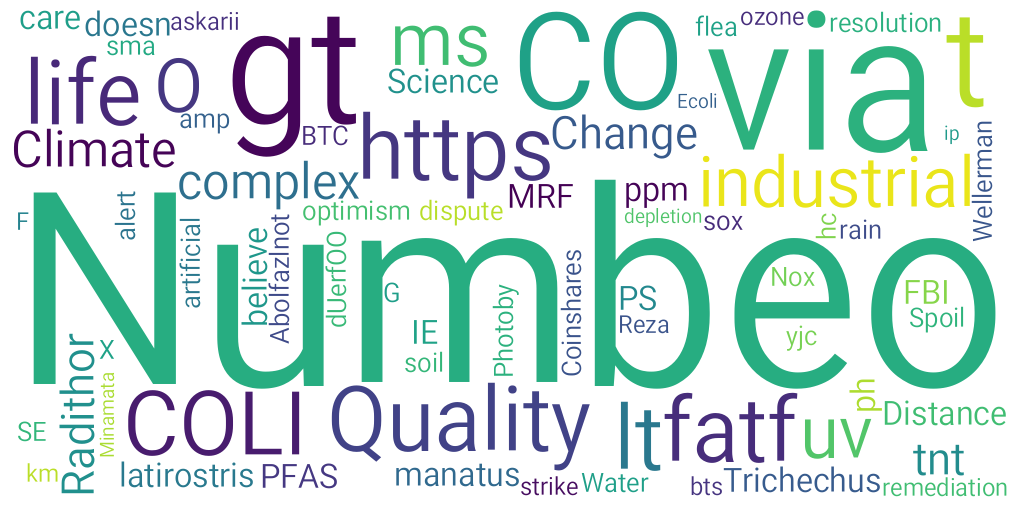

In [ ]:

drow_wordcloud(Tweets,100)